In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import sympy as sp
from IPython.display import HTML


# **Part 1: The Wave Equation**
We solve the wave equation
$$
\partial_t^2 u - c^2 \partial_x^2 u = f(t,x), \\
u(0,x) = u^0(x), \\
\partial_t u(0,x) = v^0(x)
$$
with periodic boundary conditions
$$
u(-L) = u(L).
$$

Time stepping and grids:
$$
\begin{cases}
\begin{aligned}
h &= (L - (-L)) / (M+1) = 2L/ (M+1)\\
\tau &= T / (N+1) \\
c \tau &< h \\
x_i &= a + ih && i = 0,\dots,M+1 \\
t_n &= n \tau && n = 0,\dots,N+1 \\
\end{aligned}
\end{cases}
$$

Finite Difference Scheme
$$
\begin{cases}
\begin{aligned}
\frac{U_i^{n+1} - 2 U_i^n + U_i^{n-1}}{\tau^2} - c^2 \frac{U_{i+1}^n - 2U_i^n + U_{i-1}^n}{h^2} &= f(x_i,t_n) && i = 1,\dots,M,\ n = 1,\dots,N \\
U_i^{n+1}= 2U_i^{n} - U_i^{n-1} + \frac{c^2\tau^2}{h^2} (U_{i+1}^n - 2U_i^n + U_{i-1}^n) + \tau^2 f_i^n \\
\end{aligned}
\end{cases}
$$

at t=0:
$$
\begin{cases}
\begin{aligned}
U_i^0 &= u(x_i,0) = u_i^0 && i = 1,\dots,M \\
U_0^0 &= u_0^0 \\
U_M^0 &= U_0^0 
\end{aligned}
\end{cases}
$$

i.c. on $\partial_t u$:

$$
\begin{cases}
\begin{aligned}
\frac{U^1-U^{-1}}{2\tau} &= v^0(x_i) \\
U^{-1} &= U^1 - 2 \tau v^0(x_i) \\
\end{aligned}
\end{cases}
$$

at t=1:
$$
\begin{cases}
\begin{aligned}
U^1_i = 2U_i^0 - U^{-1}_i + \frac{c^2\tau^2}{h^2} (U_{0}^n - 2U_i^0 + U_{0}^n) + \tau^2 f_i^n \\
= 2U_i^0 - U^1_i + 2\tau v_i^0 + \frac{c^2\tau^2}{h^2} (U^0_{i+1} - 2U_i^0 + U^0_{i-1}) + \tau^2f_i^0 \\
U^1_i = U_i^0 + \tau v_i^0 + \frac{c^2\tau^2}{2h^2} (U^0_{i+1} - 2U^0_i + U^0_{i-1}) + \frac{\tau^2}{2} f_i^0
\end{aligned}
\end{cases}
$$

Finite Scheme and I.C.s:
$$
\begin{cases}
\begin{aligned}
U_i^{n+1} &= 2U_i^{n} - U_i^{n-1} + \frac{c^2\tau^2}{h^2} (U_{i+1}^n - 2U_i^n + U_{i-1}^n) + \tau^2 f_i^n \\
U_i^0 &= u_i^0 && i = 1,\dots,M \\
U_0^0 &= u_0^0 \\
U_M^0 &= U_0^0 \\
U^1_i &= U_i^0 + \tau v_i^0 + \frac{c^2\tau^2}{2h^2} (U^0_{i+1} - 2U^0_i + U^0_{i-1}) + \frac{\tau^2}{2} f_i^0
\end{aligned}
\end{cases}
$$

Boundary Conditions:
$$
\begin{aligned}
U_0^{n+1} &= 2U_0^n - U_0^{n-1} + \frac{c^2\tau^2}{h^2}(U^n_{1} - 2U_0^n + U^n_{-1}) + \tau^2 f_0^n\\
U_M^{n+1} &= U_0^{n+1} \\
U_0^1 &= U_0^0 + \tau v_0^0 + \frac{c^2\tau^2}{2h^2} (U^0_{1} - 2U^0_0 + U^0_{-1}) + \frac{\tau^2}{2} f_0^0 \\
U_M^1 &= U_0^1
\end{aligned}
$$

Since it is periodic:
$$
\begin{cases}
\begin{aligned}
U_0^{n+1} &= 2U_0^n - U_0^{n-1} + \frac{c^2\tau^2}{h^2}(U^n_{1} - 2U_0^n + U^n_{M-1}) + \tau^2 f_0^n\\
U_M^{n+1} &= U_0^{n+1} \\
U_0^1 &= U_0^0 + \tau v_0^0 + \frac{c^2\tau^2}{2h^2} (U^0_{1} - 2U^0_0 + U^0_{M-1}) + \frac{\tau^2}{2} f_0^0 \\
U_M^1 &= U_0^1
\end{aligned}
\end{cases}
$$




### Final FD Scheme:

$$
\begin{cases}
\begin{aligned}
U_i^{n+1} &= 2U_i^{n} - U_i^{n-1} + \frac{c^2\tau^2}{h^2} (U_{i+1}^n - 2U_i^n + U_{i-1}^n) + \tau^2 f_i^n \\
U_i^0 &= u_i^0 && i = 1,\dots,M \\
U_0^0 &= u_0^0 \\
U_M^0 &= U_0^0 \\
U^1_i &= U_i^0 + \tau v_i^0 + \frac{c^2\tau^2}{2h^2} (U^0_{i+1} - 2U^0_i + U^0_{i-1}) + \frac{\tau^2}{2}  f_i^0 \\
U_0^{n+1} &= 2U_0^n - U_0^{n-1} + \frac{c^2\tau^2}{h^2}(U^n_{1} - 2U_0^n + U^n_{M-1}) + \tau^2 f_0^n\\
U_M^{n+1} &= U_0^{n+1} \\
U_0^1 &= U_0^0 + \tau v_0^0 + \frac{c^2\tau^2}{2h^2} (U^0_{1} - 2U^0_0 + U^0_{M-1}) + \frac{\tau^2}{2} f_0^0 \\
U_M^1 &= U_0^1
\end{aligned}
\end{cases}
$$

### Question 1
Implement the finite difference scheme above for the wave equation with periodic boundary conditions.

In [28]:
def solve_wave_equation(
    L = 1,
    T = 40,
    c = 1,
    u_0 = lambda x: np.exp(-(x**2)),
    v_0 = lambda x,c: np.zeros_like(x),
    f = lambda x, t: np.zeros_like(x),
    M = 200
    
    ):
    '''
    solve wave eq = f(t,x) on (a,b) x (0,T)
    '''

    #Initialize grids, vectors, and matrices
    h = (2*L) / (M + 1)
    N = int(c * T / h)
    tau = T / (N + 1)
    xs = np.array([-L + i * h for i in range(M + 2)])
    ts = np.array([n * tau for n in range(N + 2)])
    U = np.zeros((M + 2, N + 2))
    F = np.zeros((M+2, N+2))

    #Fill in F
    X, TT = np.meshgrid(xs, ts, indexing="ij")
    F = f(X, TT)

    # Initial condition at t = 0
    U[:, 0] = u_0(xs)
    U[M + 1, 0] = U[0, 0]

    #First time step
    U[1:M+1, 1] = (U[1:M+1, 0] + tau * v_0(xs[1:M+1],c)+ ((c**2 * tau**2) / (2 * h**2)) * (U[2:M+2, 0] - 2 * U[1:M+1, 0] + U[0:M, 0])+ (tau**2 / 2) * F[1:M+1, 0])
    U[0, 1] = (U[0, 0]+ tau * v_0(xs[0],c)+ ((c**2 * tau**2) / (2 * h**2)) * (U[1, 0] - 2 * U[0, 0] + U[M, 0])+ (tau**2 / 2) * F[0, 0])
    U[M + 1, 1] = U[0, 1]

    # Finite Difference Scheme:
    for n in range(1, N + 1):
        U[1:M+1, n+1] = (2 * U[1:M+1, n] - U[1:M+1, n-1] + ((c**2 * tau**2) / (h**2)) * (U[2:M+2, n] - 2 * U[1:M+1, n] + U[0:M, n])+ tau**2 * F[1:M+1, n])
        U[0, n+1] = (2 * U[0, n]- U[0, n-1]+ ((c**2 * tau**2) / (h**2)) * (U[1, n] - 2 * U[0, n] + U[M, n])+ tau**2 * F[0, n])
        U[M + 1, n+1] = U[0, n+1]


    return U, xs, ts





### Question 2
Test your code with the method of manufactured solutions.

Let $L = 10$, $c = 1$, $u(t,x) = \exp(-(x-ct)^2)$.
Compute the corresponding $f$, $u^0$, and $v^0$ such that $u$ solves the PDE.
Run until final time $T := L/(2c) = N\tau$.
        
Plot $U_i^N$ versus $u(t_N,x_i)$ at the grid points $x_i$ for the highest refinement level.

Original Equation:
$$
\partial_t^2 u - c^2 \partial_x^2 u = f(t,x), \\
u(0,x) = u^0(x), \\
\partial_t u(0,x) = v^0(x), \\
u(-L) = u(L).
$$

#### Work
start with the solution:
$$
u(x,t) = e^{-(x-ct)^2}
$$

compute the derivatives:
$$
\partial_t u = 2c(x-ct) e^{-(x-ct)^2} \\
\partial_t^2 u = c^2 (4(x-ct)^2-2) e^{-(x-ct)^2} \\
\partial_x u = -2(x-ct) e^{-(x-ct)^2}\\
\partial_x^2 u = (4(x-ct)^2-2) e^{-(x-ct)^2} \\ \\
$$

compute f
$$
f(t,x) = \partial_t^2 u - c^2 \partial_x^2 u \\
= (c^2 (4(x-ct)^2-2) e^{-(x-ct)^2}) - c^2 ((4(x-ct)^2-2) e^{-(x-ct)^2}) \\
= 0
$$

Find $u_0, v_0$: 
$$
u_0 = u(0,x) = e^{-(x-0)^2} = e^{-x^2} \\
v_0 = \partial_t u(0,x) = 2c(x-c 0) e^{-(x- 0)^2} = 2cxe^{-x^2}
$$


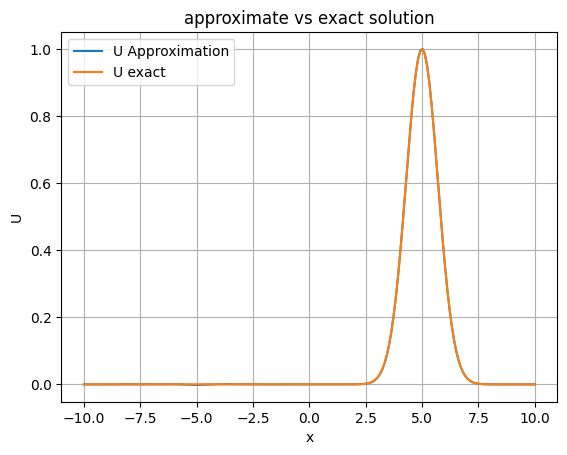

0

In [29]:
def u_exact(x, t, c):
    return np.exp(-(x-c*t)**2)

def u_0(x):
    return np.exp(-x**2)

def v_0(x,c):
    return 2*c*x*np.exp(-x**2)

def f(x,t):
    return np.zeros_like(x)


def test_wave_equation(
    L=10, 
    c=1, 
    M = 200
    ):

    T = L / (2*c)
    U_approx, xs, ts = solve_wave_equation(L,T,c,u_0,v_0, f, M)

    X, TT = np.meshgrid(xs, ts, indexing="ij")
    U_exact = u_exact(X, TT, c)


    plt.plot(xs, U_approx[:,-1], label = "U Approximation")
    plt.plot(xs, U_exact[:,-1], label = "U exact")
    plt.title("approximate vs exact solution")
    plt.xlabel("x")
    plt.ylabel("U")
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()
    return 0



test_wave_equation()


### Question 3
$$
Let
\begin{equation}
e_k := \max_{0\leq i \leq M} |U_i^N - u(t_N,x_i)|
\end{equation}
$$
denote the discrete error at the final time for mesh refinement level $k$, where we recall that $M = 2^k$.

Create a log--log plot of $e_k$ versus the mesh size $h_k := 2L/M = L / 2^{k-1}$ for $k = 10,11,12$.

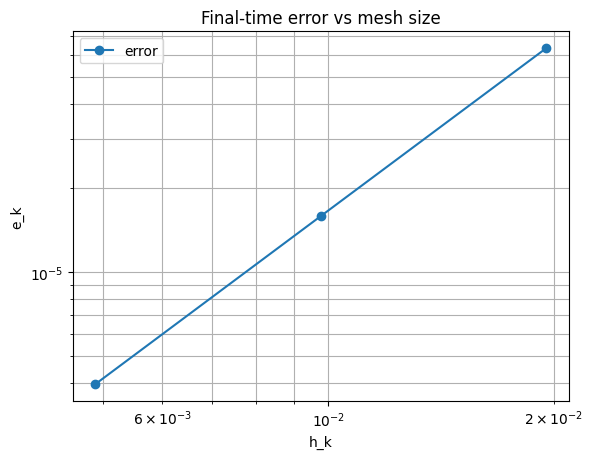

[0.01953125 0.00976562 0.00488281]
[6.32342321e-05 1.58478641e-05 3.96757142e-06]
Slope of log-log plot: + 1.9971888400370725


In [30]:
def compute_errors(L=10,c=1):
    T = L / (2 * c)
    ks = np.array([10,11,12])
    Ms = 2 ** ks
    hs = 2 * L / Ms
    errors = np.zeros(len(ks))

    for j in range(len(ks)):
        M = Ms[j]
        U_approx, xs, ts = solve_wave_equation(L,T,c,u_0,v_0,f,M)
        X, TT = np.meshgrid(xs, ts, indexing="ij")
        U_exact = u_exact(X, TT, c)
        errors[j] = np.max(np.abs(U_approx[:, -1] - U_exact[:, -1]))

    fig, ax = plt.subplots()
    ax.loglog(hs, errors, 'o-', label='error')
    ax.set_xlabel('h_k')
    ax.set_ylabel('e_k')
    ax.set_title('Final-time error vs mesh size')
    ax.grid(True, which='both')
    ax.legend()
    plt.show()

    print(hs)
    print(errors)

    slope = ( (np.log(errors[-1]) - np.log(errors[0])) / (np.log(hs[-1]) - np.log(hs[0])) )
    print(f"Slope of log-log plot: + {slope}")



    return 

compute_errors()


### Question 4
Make an animation of your approximate solution $U_i^n$.

In [31]:
def animate_wave_solution(
    L=10,
    c=1,
    M=200,
    u_0=lambda x: np.exp(-x**2),
    v_0=lambda x, c: np.zeros_like(x),
    f=lambda x, t: np.zeros_like(x)
):
    T = L / (2 * c)
    U, xs, ts = solve_wave_equation(L, T, c, u_0, v_0, f, M)

    fig, ax = plt.subplots(figsize=(8, 4))
    line, = ax.plot(xs, U[:, 0], label='Approximate solution')
    ax.set_xlim(xs[0], xs[-1])
    ax.set_ylim(np.min(U) - 0.1, np.max(U) + 0.1)
    ax.set_xlabel('x')
    ax.set_ylabel('U(x,t)')
    title = ax.set_title(f't = {ts[0]:.3f}')
    ax.grid(True)
    ax.legend()

    def update(n):
        line.set_ydata(U[:, n])
        title.set_text(f't = {ts[n]:.3f}')
        return line, title

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(ts),
        interval=30,
        blit=False
    )

    plt.close(fig)
    return HTML(ani.to_jshtml())

animate_wave_solution(L=10, c=1, M=200, u_0=u_0, v_0=v_0, f=f)

### Question 5
Now set $f(t,x) = 0$ and $v^0 = 0$.
	      Experiment with different periodic initial conditions $u^0$.
	      Take snapshots of your simulations and create animations over the circle in 3d.

Since we are modeling periodic solutions, we can plot them over a circle of circumference $2\pi r = 2L$ in 3D in the following way. 

We let $s \in [-L, L]$ denote our spatial coordinate, so that our discrete grid points are denoted by $s_i$, and $U_i^n$ denotes the approximation to $u(t_n, s_i)$. Then, $s$ corresponds to an arc length coordinate $s = r\theta$ on the circle of radius $r = L/\pi$. 

By making the transformation 
$$
s \mapsto \left( r \cos \frac{s}{r}, r \sin \frac{s}{r} \right), \tag{10}
$$ 

we can map our 2D points 
$$
(s_i, U_i^n) \mapsto \left( r \cos \frac{s_i}{r}, r \sin \frac{s_i}{r}, U_i^n \right), \tag{11}
$$ 

to obtain a plot of our discrete solution over the circle in 3D.


In [36]:
def animate_over_circle(t_values,s_values,u_values):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.set_title('t = {:.2f}'.format(t_values[0]))
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('u')
    z_min = min(min(u_value) for u_value in u_values)
    z_min -= 0.1 if abs(z_min) < 0.1 else 0.1 * abs(z_min)
    z_max = max(max(u_value) for u_value in u_values)
    z_max += 0.1 if abs(z_max) < 0.1 else 0.1 * abs(z_max)
    ax.set_zlim(z_min,z_max)
    L = -s_values[0]
    r = L /np.pi
    xs = r * np.cos(s_values / r)
    ys = r * np.sin(s_values / r)
    s = xs

    line, = ax.plot(xs, ys, u_values[0], lw=2)
    def animate(frame):
        ax.set_title(f't = {t_values[frame]:.2f}')
        line.set_data_3d(xs, ys, u_values[frame])
        return (line,)

    anim = animation.FuncAnimation(
        fig, animate, frames=len(u_values), interval=60, blit=False
    )

    html = HTML(anim.to_jshtml())
    html._anim = anim
    plt.close(fig)
    return html

L=10
c = 1
T = L / (2*c)
k=6
M = 2**k
h = (2*L) / (M)

U, xs, ts = solve_wave_equation(L, T, c, u_0, v_0, f, M)

animate_over_circle(ts,xs,U.T) 
